# Weekly ETF Risk Monitor: End-to-End Project Pipeline

**Sole author:** Paritosh Dwivedi

## Objective and stakeholder question

This notebook builds a reproducible SPY risk-monitoring pipeline for a portfolio manager's weekly review.

**Decision question:** Should the portfolio manager maintain the current SPY exposure or investigate reducing it because near-term risk appears elevated?

**Success criteria:** validated immutable raw data, reproducible processed data, chronological out-of-sample evaluation, a clear current risk signal, and explicit assumptions and limitations.

In [1]:
# --- run me first: makes this notebook work wherever it lives ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import pandas as pd
from IPython.display import Image, display

from run_pipeline import run
from src.config import get_settings

settings = get_settings()
print('working from:', ROOT.name)
print('sole author: Paritosh Dwivedi')

working from: project
sole author: Paritosh Dwivedi


## Analysis plan

1. Acquire or reload a recorded daily SPY snapshot.
2. Validate schema, types, missingness, duplicates, ordering, and price ranges.
3. Clean without modifying the raw artifact.
4. Retain plausible tail observations and flag extreme returns.
5. Build lagged and rolling features without look-ahead.
6. Predict five-day realized volatility with Ridge regression.
7. Classify elevated-risk weeks using a training-derived threshold.
8. Compare with simple baselines and test threshold sensitivity.
9. Translate the latest result into a stakeholder decision signal.

The smallest complete baseline is executed before any optional model expansion.

## 1. Execute the complete reproducible pipeline

The default run uses the latest validated raw snapshot. Pass `refresh=True` only when a new provider pull is intended; each refresh creates a new immutable raw file.

In [2]:
metrics = run(refresh=False)
print('pipeline completed for:', metrics['ticker'])
print('generated at:', metrics['generated_at_utc'])

pipeline completed for: SPY
generated at: 2026-08-17T22:45:10.580274+00:00


## 2. Data source and validation

In [3]:
data_summary = {
    'provider': metrics['data']['acquisition'].get('provider'),
    'raw_file': metrics['data']['raw_file'],
    'rows': metrics['data']['rows_raw'],
    'date_start': metrics['data']['date_start'],
    'date_end': metrics['data']['date_end'],
    'validation_passed': metrics['data']['raw_validation']['valid'],
    'missing_values': metrics['data']['raw_validation']['missing_values'],
    'duplicate_dates': metrics['data']['raw_validation']['duplicate_dates'],
}
pd.Series(data_summary, name='value').to_frame()

,value
provider,yfinance
raw_file,data/raw/spy_daily_20260817T224143Z.csv
rows,4180
date_start,2010-01-04
date_end,2026-08-17
validation_passed,True
missing_values,0
duplicate_dates,0


The raw file is preserved under `data/raw/` with a retrieval timestamp and SHA-256 manifest. Processed outputs are derived by code and can be regenerated.

In [4]:
processed = pd.read_parquet(ROOT / metrics['data']['model_dataset_file'])
display(processed[['date', 'adjusted_close', 'daily_return', 'rolling_vol_20', 'drawdown', 'target_next_week_vol']].tail())
print('processed rows:', len(processed))
print('flagged retained return outliers:', metrics['data']['return_outliers_flagged'])

,date,adjusted_close,daily_return,rolling_vol_20,drawdown,target_next_week_vol
4175,2026-08-11,770.559998,-0.003195,0.140565,-0.003492,NaN
4176,2026-08-12,772.489990,0.002505,0.140286,-0.000996,NaN
4177,2026-08-13,777.880005,0.006977,0.139455,0.000000,NaN
4178,2026-08-14,776.340027,-0.001980,0.133304,-0.001980,NaN
4179,2026-08-17,772.669983,-0.004727,0.134933,-0.006698,NaN


processed rows: 4180
flagged retained return outliers: 31


## 3. Market and risk context

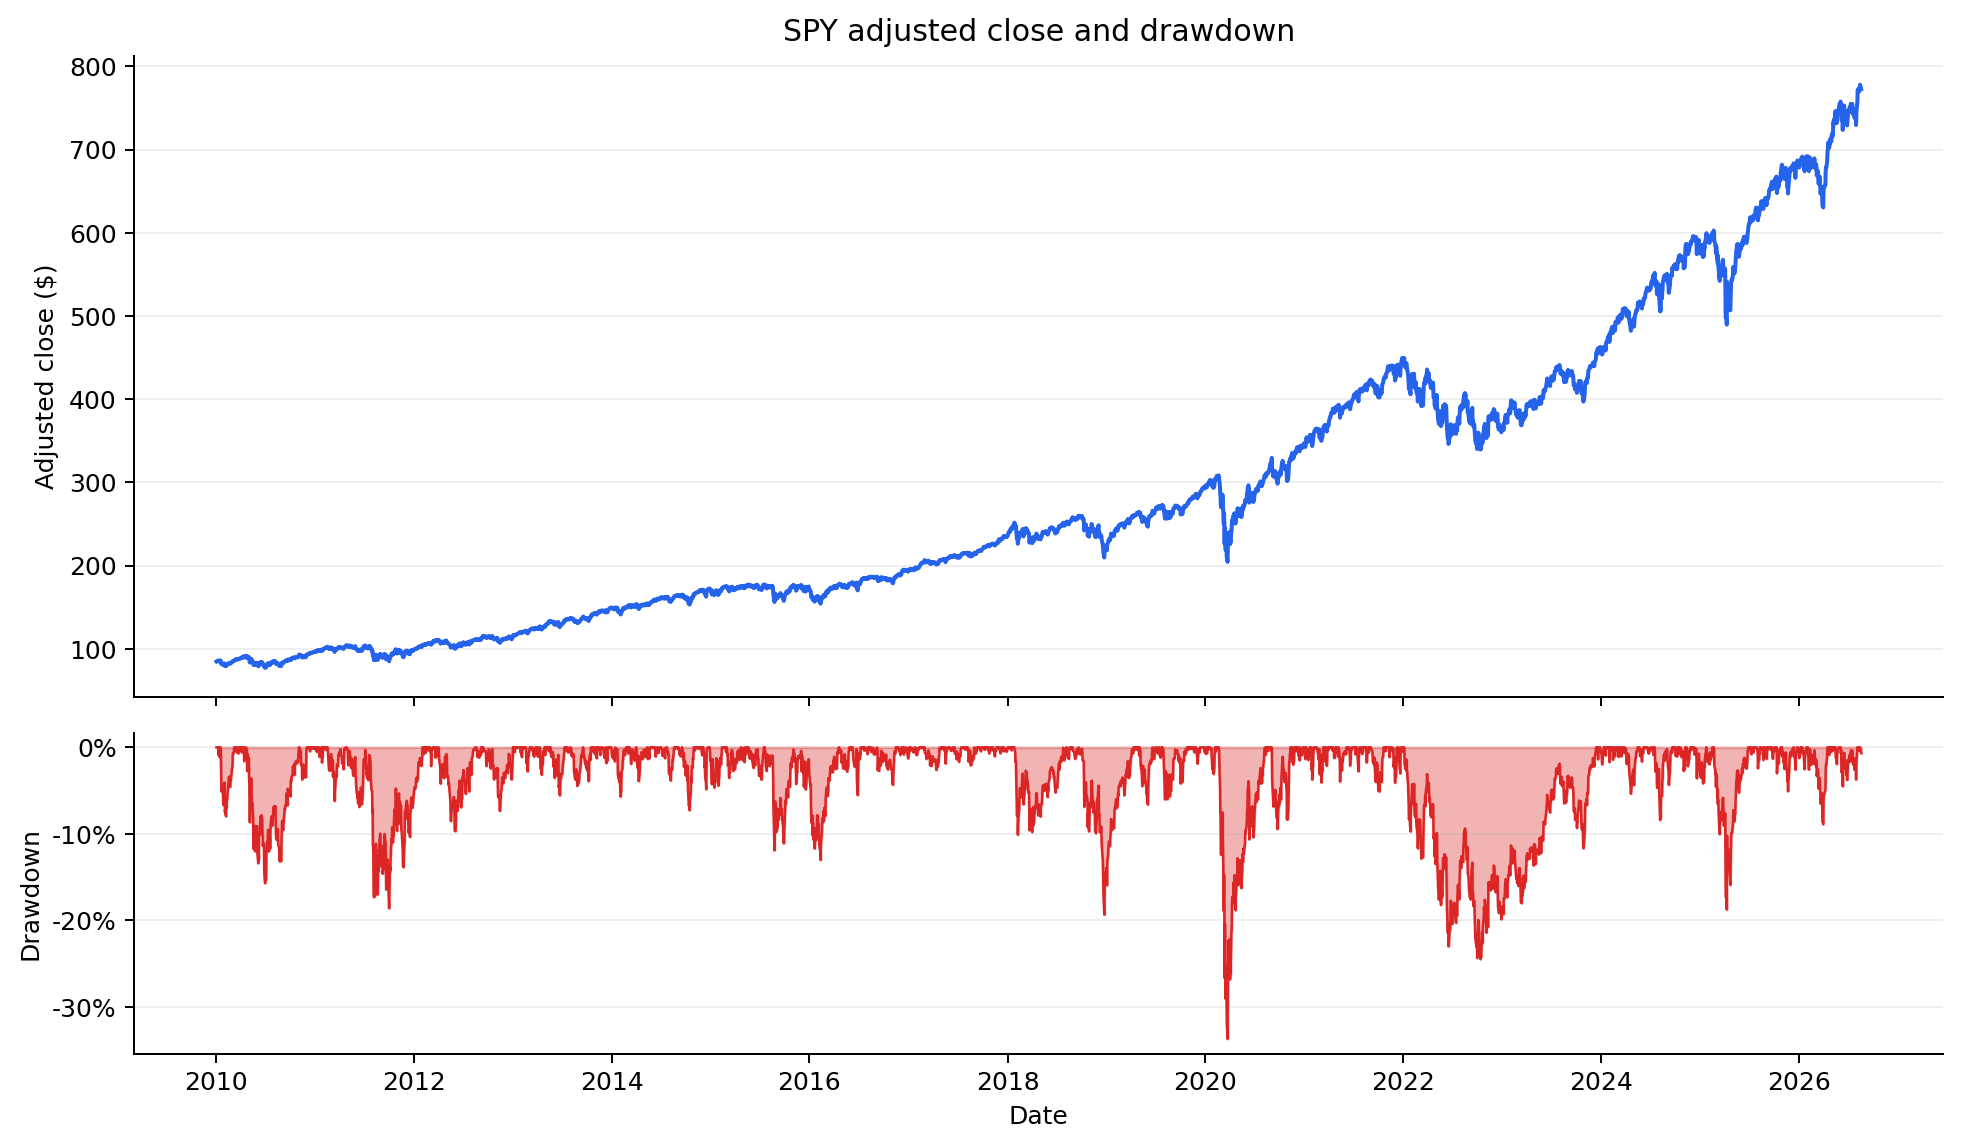

In [5]:
display(Image(filename=str(ROOT / 'reports/images/price_and_drawdown.png'), width=900))

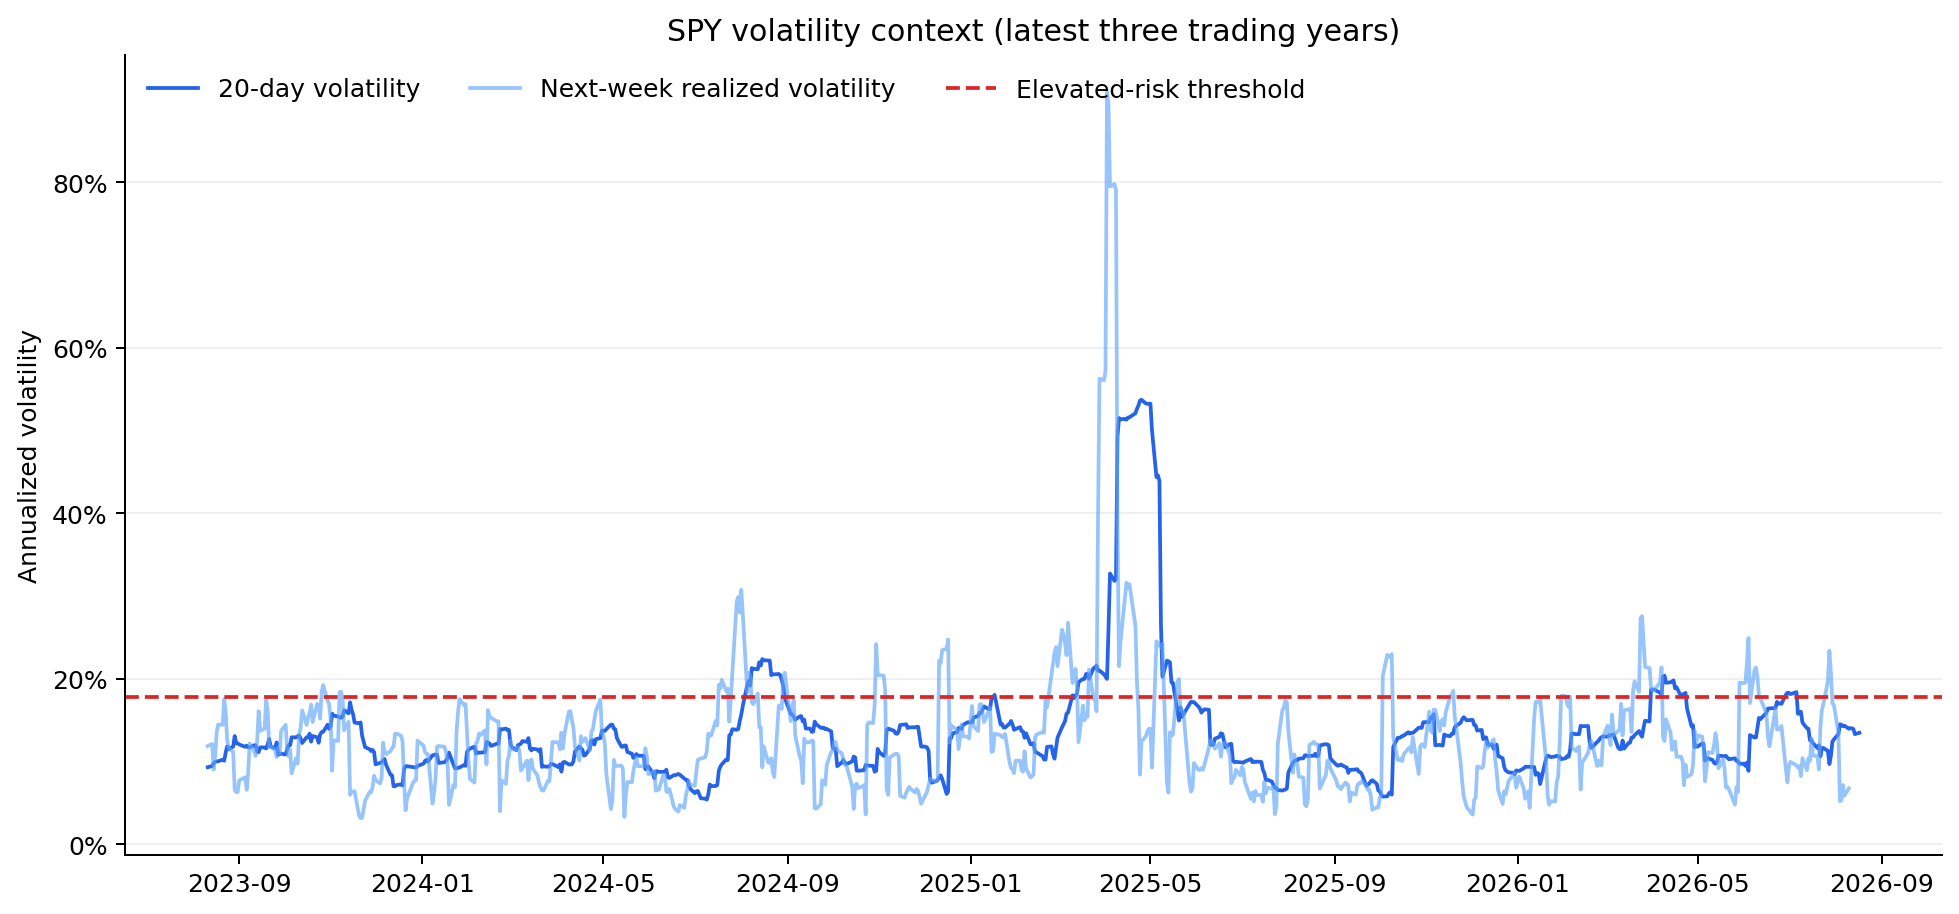

In [6]:
display(Image(filename=str(ROOT / 'reports/images/volatility_and_risk_threshold.png'), width=900))

Plausible extremes are retained because tail events are central to risk decisions. The robust outlier flag supports diagnosis and sensitivity analysis without deleting market stress.

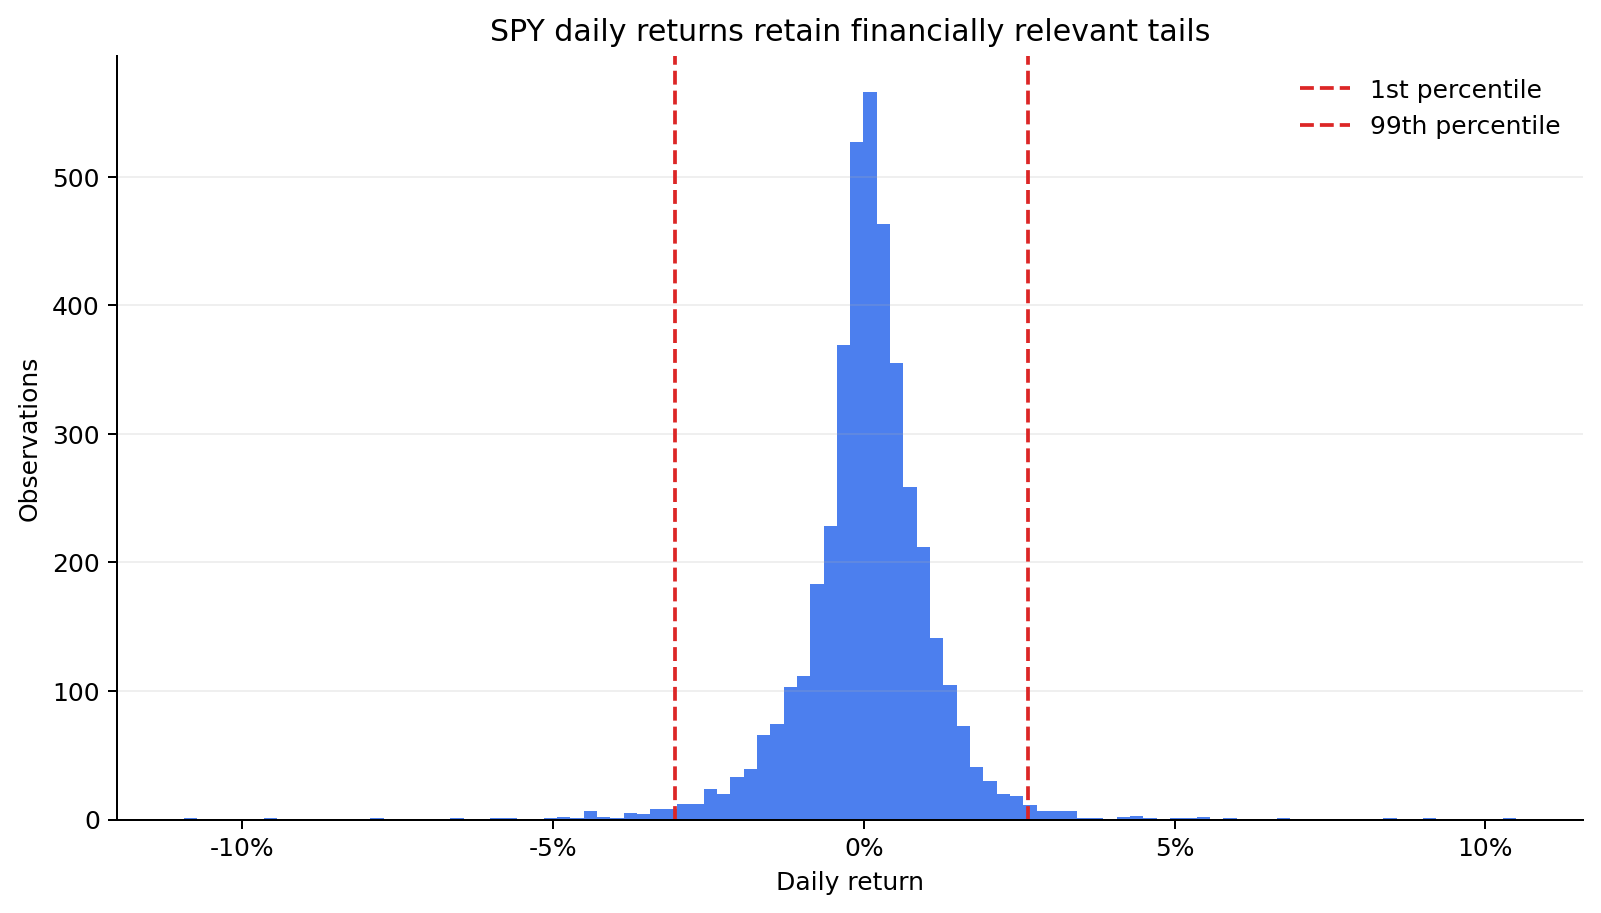

In [7]:
display(Image(filename=str(ROOT / 'reports/images/return_distribution.png'), width=800))

## 4. Chronological model evaluation

In [8]:
regression = metrics['models']['regression']
regression_table = pd.DataFrame({
    'Ridge': regression['ridge'],
    'Recent-vol baseline': regression['recent_volatility_baseline'],
    'Historical-mean baseline': regression['historical_mean_baseline'],
}).T
display(regression_table.round(4))
print(f"Ridge MAE improvement vs recent-vol baseline: {regression['ridge_mae_improvement_vs_recent']:.1%}")

,mae,rmse,r2
Ridge,0.0402,0.0659,0.3350
Recent-vol baseline,0.0507,0.0864,-0.1447
Historical-mean baseline,0.0517,0.0821,-0.0334


Ridge MAE improvement vs recent-vol baseline: 20.7%


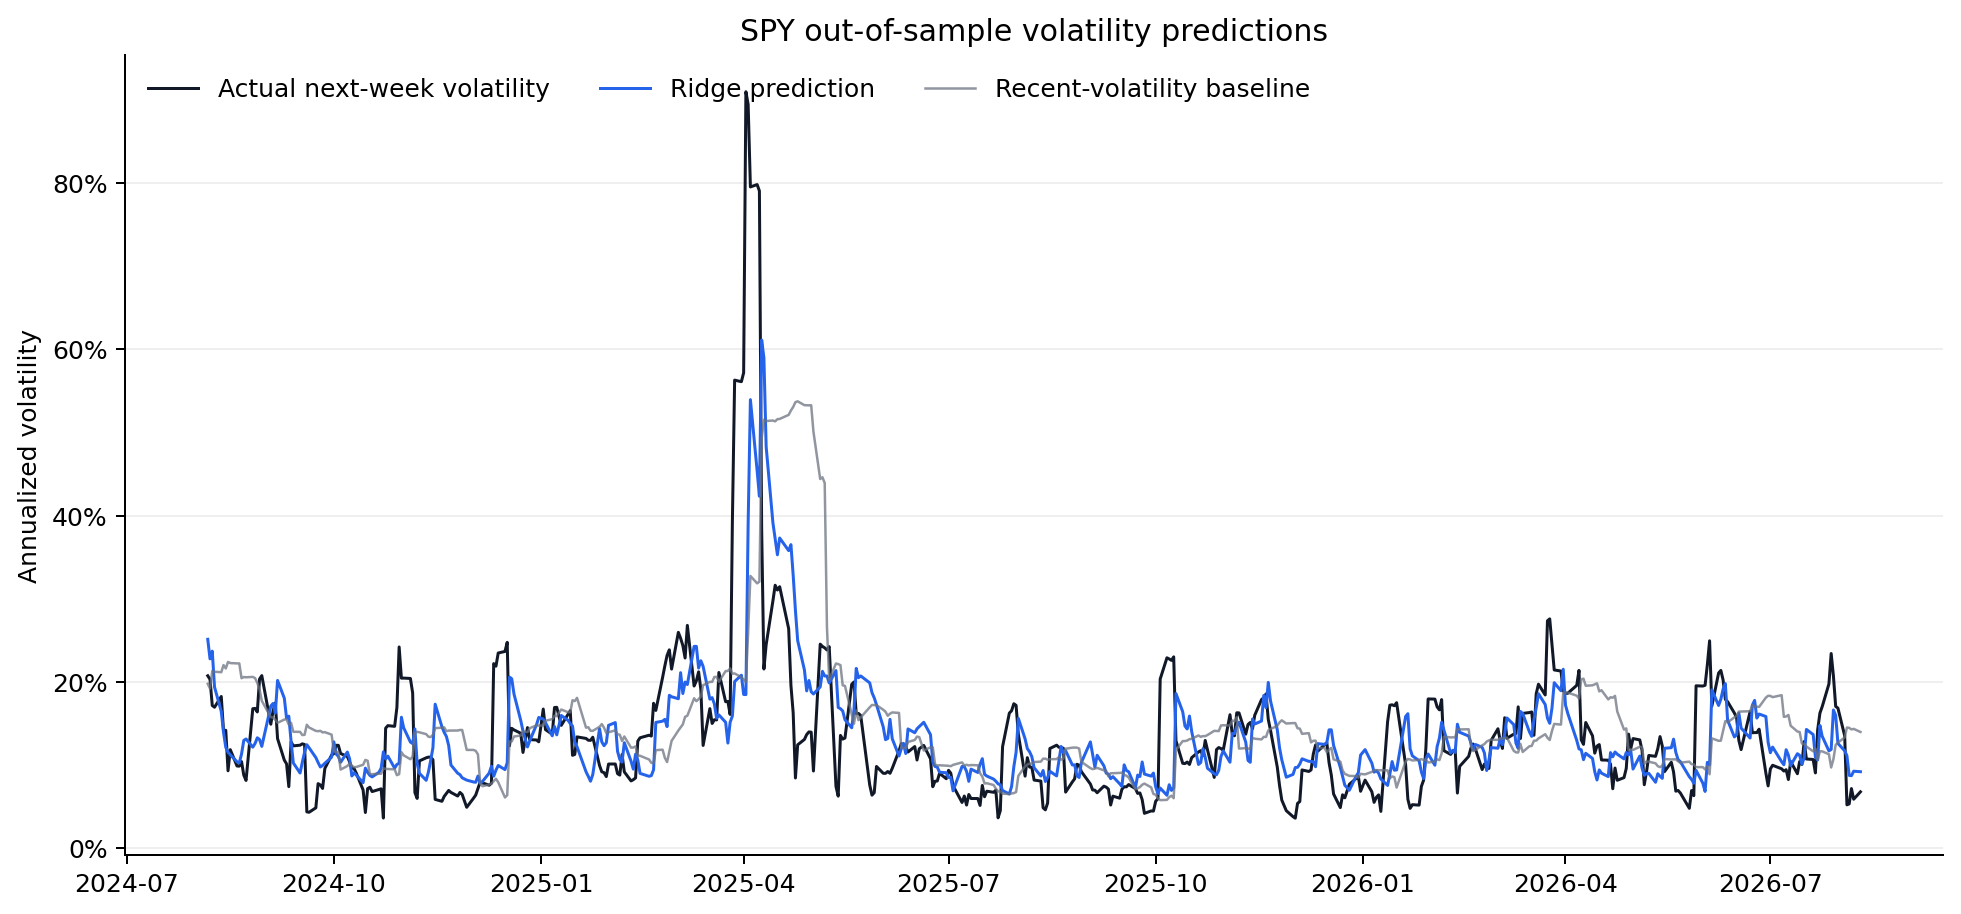

In [9]:
display(Image(filename=str(ROOT / 'reports/images/regression_predictions.png'), width=900))

The split is chronological: training observations precede test observations. The recent-volatility baseline represents the simple time-series answer; Ridge must improve on it to justify added complexity.

In [10]:
classification = metrics['models']['classification']
classification_table = pd.DataFrame({
    'Logistic model': classification['logistic'],
    'Prior baseline': classification['prior_baseline'],
}).T
display(classification_table.round(3))

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
Logistic model,0.811,0.723,0.37,0.604,0.459,0.777
Prior baseline,0.867,0.500,0.00,0.000,0.000,0.500


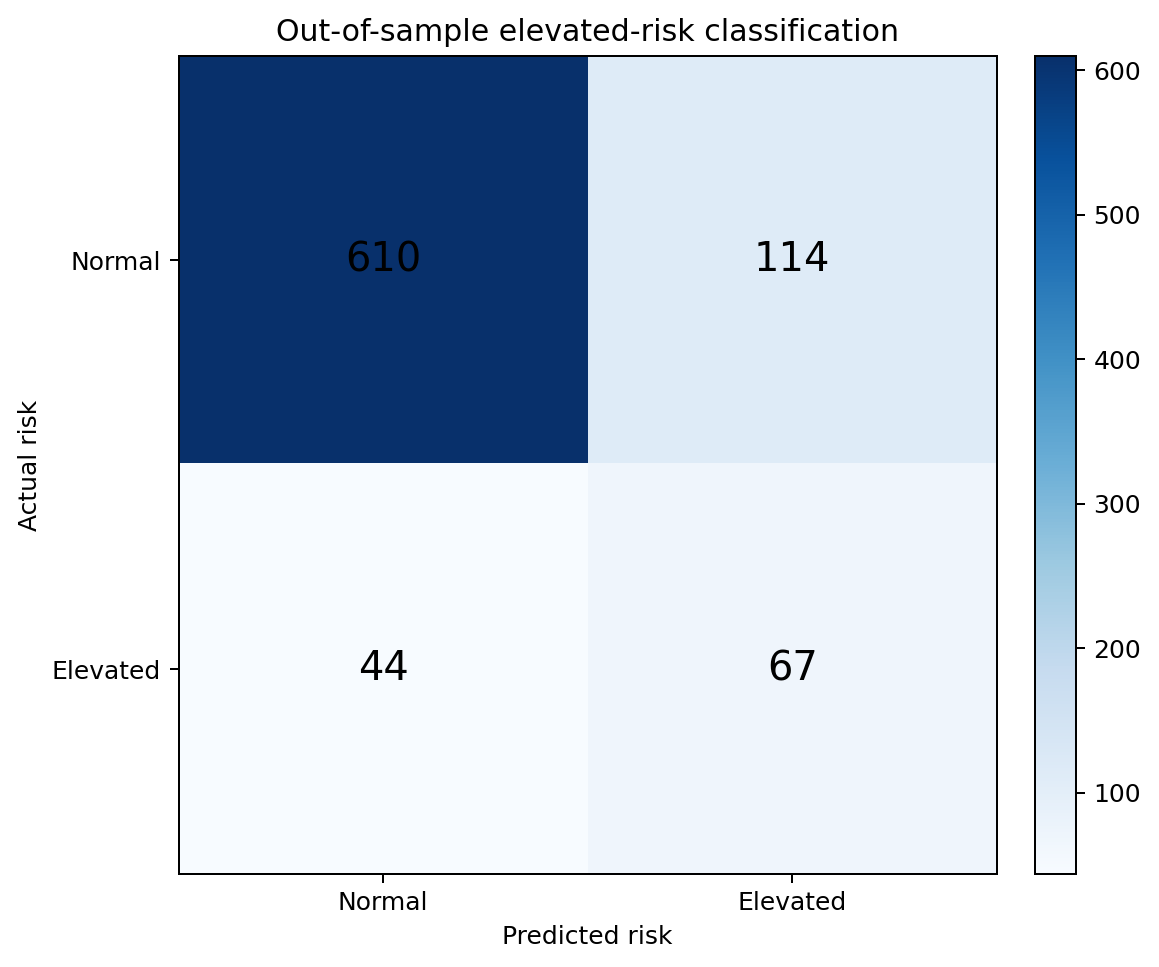

In [11]:
display(Image(filename=str(ROOT / 'reports/images/classification_confusion_matrix.png'), width=600))

## 5. Risk-threshold sensitivity

In [12]:
sensitivity = pd.DataFrame(metrics['sensitivity'])
formatted_sensitivity = sensitivity.copy()
for column in formatted_sensitivity.columns:
    formatted_sensitivity[column] = formatted_sensitivity[column].map(lambda value: f'{value:.1%}')
display(formatted_sensitivity)

,risk_quantile,risk_threshold_annualized_vol,balanced_accuracy,precision,recall,f1
0,70.0%,16.3%,70.6%,44.8%,58.4%,50.7%
1,75.0%,17.8%,72.3%,37.0%,60.4%,45.9%
2,80.0%,19.7%,72.6%,32.8%,57.1%,41.7%


Threshold choice changes precision and recall, so the classification is a relative warning signal rather than a universal definition of danger.

## 6. Current stakeholder signal

In [13]:
snapshot = metrics['latest_risk_snapshot']
pd.Series({
    'As-of date': snapshot['as_of_date'],
    'SPY adjusted close': f"${snapshot['adjusted_close']:,.2f}",
    '20-day annualized volatility': f"{snapshot['rolling_vol_20']:.1%}",
    'Predicted next-week volatility': f"{snapshot['predicted_next_week_vol']:.1%}",
    'Elevated-risk probability': f"{snapshot['elevated_risk_probability']:.1%}",
    'Training-derived threshold': f"{snapshot['risk_threshold_annualized_vol']:.1%}",
    'Classification': snapshot['risk_classification'].upper(),
    'Decision language': snapshot['decision_language'],
}, name='value').to_frame()

,value
As-of date,2026-08-17
SPY adjusted close,$772.67
20-day annualized volatility,13.5%
Predicted next-week volatility,11.1%
Elevated-risk probability,22.2%
Training-derived threshold,17.8%
Classification,NORMAL
Decision language,The model does not flag elevated risk; maintai...


## 7. Assumptions, risks, and conclusion

- The five-trading-day horizon approximates a weekly review cycle.
- Provider data and adjusted prices may be revised after retrieval.
- Historical relationships can break during regime changes.
- The 75th-percentile label is training-derived and sensitive to the selected quantile.
- A normal signal does not mean the position is safe; it means the model does not detect elevated relative risk under its historical definition.
- The output is decision support, not an automated trade or guarantee.

The final recommendation is stored in `reports/final_summary.md`. The complete assumptions and risk register are maintained under `docs/`.

In [14]:
print(snapshot['decision_language'])

The model does not flag elevated risk; maintain exposure only within the existing mandate.


## Next steps

- Revisit the target threshold if the stakeholder supplies an explicit risk limit.
- Monitor provider schema and model performance after each refresh.
- Add a benchmark ETF only if it improves the decision rather than expanding scope.
- Stop model expansion when added complexity does not improve chronological out-of-sample evidence.